# TAO ADCP Velocity: EUC-Space Statistics
Analysis relative to the Equatorial Undercurrent (EUC) core, identified at each time step
as the depth of maximum eastward (positive) zonal velocity at each mooring.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from scipy import stats, interpolate
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

## Configuration

In [2]:
DATA_DIR = Path('/data/SO3/edavenport/TAO_2012to2016_daily')
FIG_DIR  = Path('2012to2016/EUC_space_figures')

for subdir in ['overview', 'profiles', 'correlations', 'cross_correlation']:
    (FIG_DIR / subdir).mkdir(parents=True, exist_ok=True)

MOORING_FILES = {
    '170°W': 'ADCP_2012to2016_0N170W_daily.cdf',
    '140°W': 'ADCP_2012to2016_0N140W_daily.cdf',
    '110°W': 'ADCP_2012to2016_0N110W_daily.cdf',
}
MOORINGS = list(MOORING_FILES.keys())

PAIRS       = [('170°W', '140°W'), ('170°W', '110°W'), ('140°W', '110°W')]
PAIR_LABELS = ['170°W – 140°W', '170°W – 110°W', '140°W – 110°W']

MOORING_COLORS = dict(zip(MOORINGS, sns.color_palette('colorblind', 3)))
PAIR_COLORS    = sns.color_palette('Set2', 3)
PAIR_LS = ['-', '-', '-']

EUC_OFFSETS = [-80, -40, 0, 40]
EUC_LABELS  = ['core − 80 m', 'core − 40 m', 'EUC core', 'core + 40 m']

# asymmetric diverging norm: vmin=-2 shows La Niña blues, vmax=3 shows El Niño reds
ONI_CMAP = 'RdBu_r'
ONI_NORM = TwoSlopeNorm(vcenter=0, vmin=-2, vmax=3)

sns.set_style('ticks')
sns.set_context('notebook', font_scale=1.05)
SAVE_KW = dict(dpi=150, bbox_inches='tight')

## Load Data

In [3]:
datasets = {}
for label, fname in MOORING_FILES.items():
    datasets[label] = xr.open_dataset(DATA_DIR / fname).squeeze(['lat', 'lon'])

# convert cm/s → m/s; NaN already applied where quality flag == 0
u = {k: ds['u_1205'] * 0.01 for k, ds in datasets.items()}
v = {k: ds['v_1206'] * 0.01 for k, ds in datasets.items()}

for label, ds in datasets.items():
    t0 = np.datetime_as_string(ds.time.values[0],  unit='D')
    t1 = np.datetime_as_string(ds.time.values[-1], unit='D')
    print(f"{label}: {t0} – {t1}  depth {ds.depth.values[0]:.0f}–{ds.depth.values[-1]:.0f} m")

170°W: 2012-01-01 – 2016-12-31  depth 10–315 m
140°W: 2012-01-01 – 2016-04-04  depth 10–295 m
110°W: 2012-01-01 – 2016-12-31  depth 10–315 m


## ONI Index

In [4]:
# Center-month mapping: DJF→Jan, JFM→Feb, ..., NDJ→Dec for the listed year
# 2011 included to anchor interpolation at record start
ONI_MONTHLY_RAW = {
    2011: [-1.3, -1.0, -0.8, -0.6, -0.5, -0.4, -0.4, -0.6, -0.8, -1.0, -1.0, -0.9],
    2012: [-0.7, -0.6, -0.5, -0.4, -0.2,  0.1,  0.3,  0.4,  0.4,  0.3,  0.1, -0.1],
    2013: [-0.3, -0.3, -0.2, -0.2, -0.3, -0.3, -0.4, -0.3, -0.2, -0.1, -0.1, -0.2],
    2014: [-0.3, -0.3, -0.1,  0.2,  0.3,  0.2,  0.1,  0.1,  0.3,  0.5,  0.7,  0.8],
    2015: [ 0.7,  0.6,  0.7,  0.8,  1.0,  1.3,  1.6,  1.9,  2.2,  2.5,  2.6,  2.8],
    2016: [ 2.6,  2.3,  1.7,  1.0,  0.5,  0.0, -0.3, -0.5, -0.6, -0.6, -0.6, -0.5],
}

_dates, _vals = [], []
for year, monthly in ONI_MONTHLY_RAW.items():
    for month, val in enumerate(monthly, start=1):
        _dates.append(pd.Timestamp(year, month, 15))
        _vals.append(val)

_oni_monthly = pd.Series(_vals, index=pd.DatetimeIndex(_dates)).sort_index()
_daily_idx   = pd.date_range('2012-01-01', '2016-12-31', freq='D')
oni_daily = (
    _oni_monthly
    .reindex(_oni_monthly.index.union(_daily_idx))
    .interpolate(method='time')
    .reindex(_daily_idx)
)


def get_oni(time_vals):
    """Look up linearly interpolated ONI for an array of numpy datetime64 values."""
    return oni_daily.reindex(pd.DatetimeIndex(time_vals).normalize()).values


print(f"ONI 2012–2016: {oni_daily.min():.2f} to {oni_daily.max():.2f} °C")

ONI 2012–2016: -0.79 to 2.80 °C


## Helper Functions

In [5]:
def find_euc_core(da, min_depth=30.0):
    """
    Depth of maximum eastward velocity at each time step.
    Restricted to depth >= min_depth; returns NaN where max u <= 0 or data is sparse.
    """
    depths   = da.depth.values
    da_sub   = da.isel(depth=depths >= min_depth)
    sub_d    = da_sub.depth.values
    arr      = da_sub.values.astype(float)  # (time, depth)
    core     = np.full(arr.shape[0], np.nan)

    for t in range(arr.shape[0]):
        row   = arr[t]
        valid = np.isfinite(row)
        if valid.sum() >= 2:
            idx = np.nanargmax(row)
            if row[idx] > 0:
                core[t] = sub_d[idx]
    return core


def sample_euc_relative(da, core_depths, offsets):
    """
    At each time step, linearly interpolate da at core_depth + offset for each offset.
    Returns dict: {offset: np.array(n_time)} with NaN where interpolation fails.
    """
    depths = da.depth.values
    arr    = da.values.astype(float)
    n_time = arr.shape[0]
    result = {off: np.full(n_time, np.nan) for off in offsets}

    for t in range(n_time):
        if np.isnan(core_depths[t]):
            continue
        row   = arr[t]
        valid = np.isfinite(row)
        if valid.sum() < 3:
            continue
        f = interpolate.interp1d(
            depths[valid], row[valid], kind='linear',
            bounds_error=False, fill_value=np.nan
        )
        for off in offsets:
            val = float(f(core_depths[t] + off))
            if np.isfinite(val):
                result[off][t] = val
    return result


def align_pair_1d(ts1, t1, ts2, t2):
    """Align two 1-D time series to their common time steps. Returns (x, y, mask, t_common)."""
    t_common, idx1, idx2 = np.intersect1d(t1, t2, return_indices=True)
    x = ts1[idx1].astype(float)
    y = ts2[idx2].astype(float)
    m = np.isfinite(x) & np.isfinite(y)
    return x, y, m, t_common


def lagged_xcorr_1d(ts1, ts2, max_lag=365):
    """
    Normalized lagged cross-correlation of two 1-D arrays (same length, pre-aligned).
    NaN gaps zero-filled after demeaning by co-valid mean.
    """
    m = np.isfinite(ts1) & np.isfinite(ts2)
    if m.sum() < max_lag * 2:
        return None, None
    x = ts1 - np.nanmean(ts1[m])
    y = ts2 - np.nanmean(ts2[m])
    x[~np.isfinite(x)] = 0.0
    y[~np.isfinite(y)] = 0.0
    xcorr = np.correlate(x, y, mode='full')
    lags  = np.arange(-(len(x) - 1), len(x))
    norm  = np.sqrt(np.dot(x, x) * np.dot(y, y))
    if norm > 0:
        xcorr /= norm
    sel = np.abs(lags) <= max_lag
    return lags[sel], xcorr[sel]

def to_euc_relative(da, core_depths, z_rel_grid):
    """
    Re-index da from absolute depth onto EUC-relative depth at each time step.
    z_rel = z - z_EUC(t), so the EUC core always sits at z_rel = 0.
    Returns (n_time, n_z_rel) array; NaN where core not found or out of depth range.
    """
    depths = da.depth.values
    arr    = da.values.astype(float)
    result = np.full((arr.shape[0], len(z_rel_grid)), np.nan)
    for t in range(arr.shape[0]):
        if np.isnan(core_depths[t]):
            continue
        row   = arr[t]
        valid = np.isfinite(row)
        if valid.sum() < 3:
            continue
        z_shifted = depths[valid] - core_depths[t]
        f = interpolate.interp1d(z_shifted, row[valid], kind='linear',
                                 bounds_error=False, fill_value=np.nan)
        result[t] = f(z_rel_grid)
    return result


## 1 — EUC Core Identification

In [6]:
# find raw EUC core depth at each time step for each mooring
_euc_core_raw = {label: find_euc_core(u[label]) for label in MOORINGS}

# 30-day running mean: smooths transient surface current spikes
euc_core = {
    label: pd.Series(_euc_core_raw[label]).rolling(30, center=True, min_periods=15).mean().values
    for label in MOORINGS
}


for label in MOORINGS:
    c = euc_core[label]
    valid_frac = np.mean(np.isfinite(c))
    print(f"{label}: EUC core found {valid_frac:.1%} of days  "
          f"mean depth {np.nanmean(c):.1f} m  "
          f"range {np.nanmin(c):.0f}–{np.nanmax(c):.0f} m")

170°W: EUC core found 97.6% of days  mean depth 138.4 m  range 77–192 m
140°W: EUC core found 88.2% of days  mean depth 97.5 m  range 38–143 m
110°W: EUC core found 100.0% of days  mean depth 67.2 m  range 38–100 m


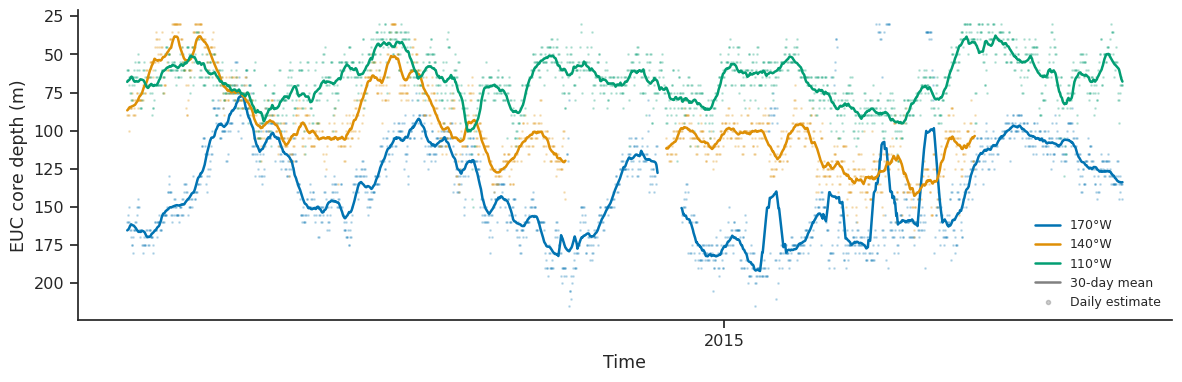

Saved: overview/euc_core_depth.png


In [7]:
from matplotlib.lines import Line2D as _L2D

fig, ax = plt.subplots(figsize=(12, 4))

for label, color in MOORING_COLORS.items():
    t_vals = u[label].time.values
    # faint scatter = raw daily estimate; solid line = 10-day running mean
    ax.scatter(t_vals, _euc_core_raw[label], color=color, s=1.0, alpha=0.2, rasterized=True)
    ax.plot(t_vals, euc_core[label], color=color, lw=1.8, label=label)

ax.set_xlabel("Time")
ax.set_ylabel("EUC core depth (m)")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
sns.despine(ax=ax)

handles, labels_ = ax.get_legend_handles_labels()
handles += [
    _L2D([0],[0], color="gray", lw=1.8, label="30-day mean"),
    _L2D([0],[0], color="gray", lw=0, marker="o", ms=3, alpha=0.4, label="Daily estimate"),
]
ax.legend(handles=handles, frameon=False, fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / "overview" / "euc_core_depth.png", **SAVE_KW)
plt.show()
print("Saved: overview/euc_core_depth.png")

## 2 — Time-Depth Diagrams with EUC Core Overlay

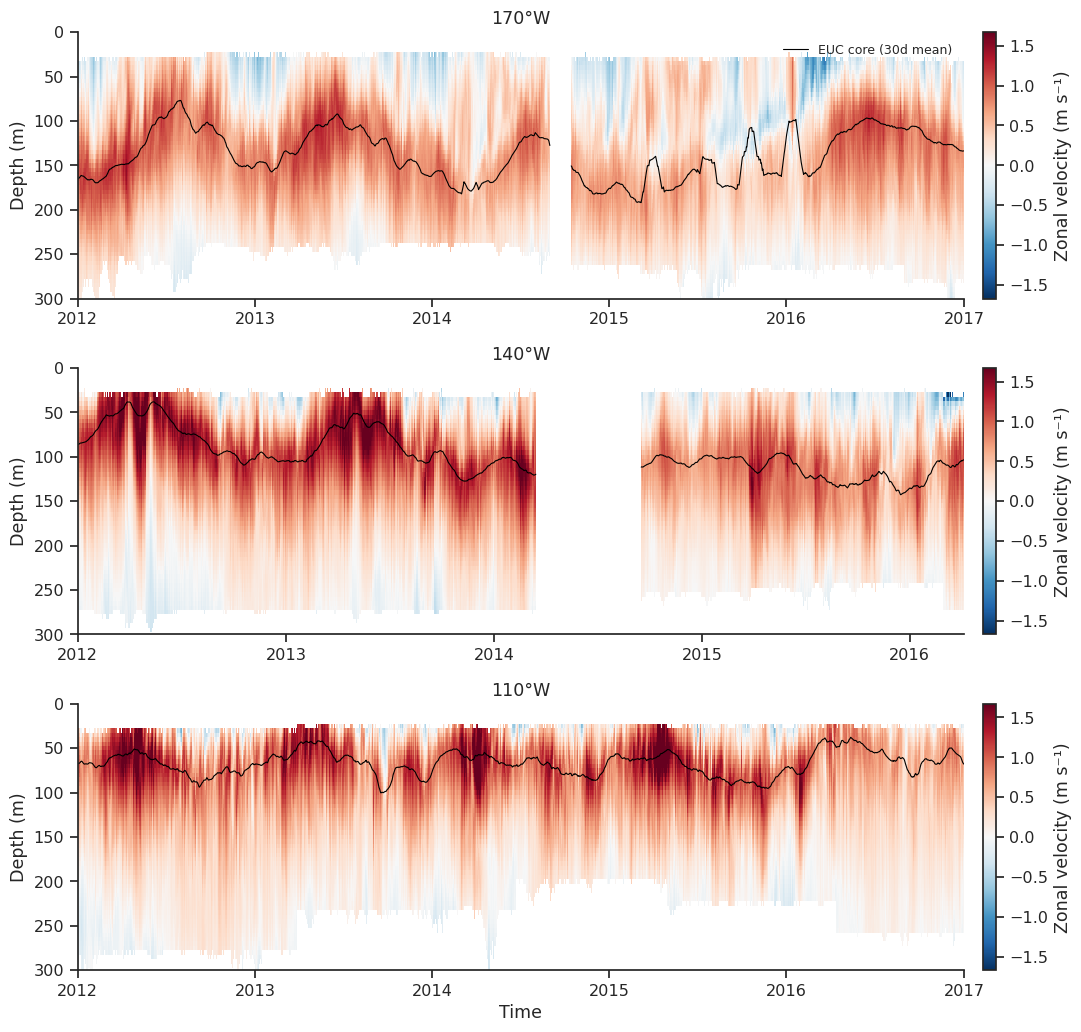

Saved: overview/timeseries_u.png


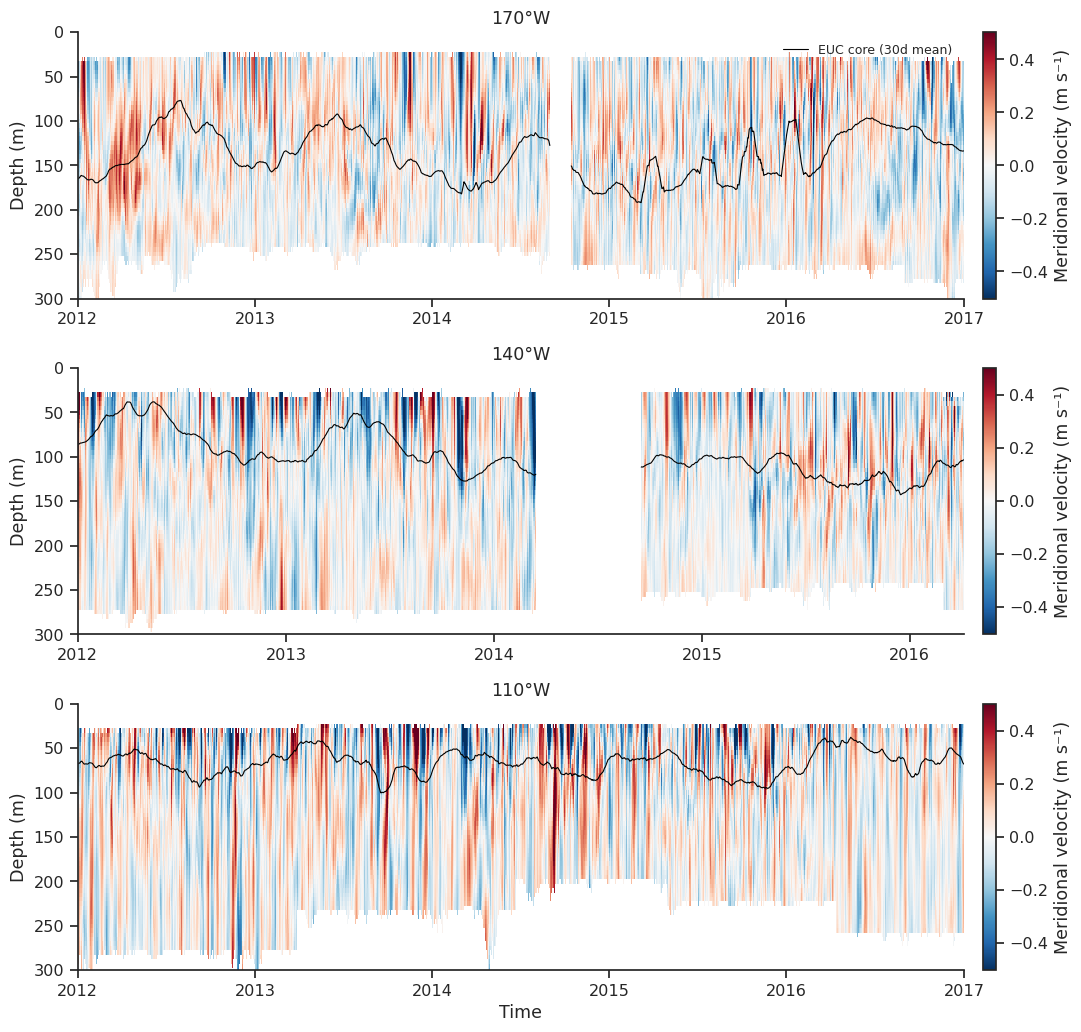

Saved: overview/timeseries_v.png


In [8]:
u_vmax = max(float(np.nanpercentile(np.abs(da.values), 99)) for da in u.values())
v_vmax = max(float(np.nanpercentile(np.abs(da.values), 99)) for da in v.values())

for data_dict, vmax, cbar_label, fname in [
    (u, u_vmax, "Zonal velocity (m s⁻¹)",      "timeseries_u.png"),
    (v, v_vmax, "Meridional velocity (m s⁻¹)", "timeseries_v.png"),
]:
    n   = len(data_dict)
    fig, axes = plt.subplots(n, 1, figsize=(11, 3.5 * n), sharey=True)
    for ax, label in zip(axes, data_dict):
        da = data_dict[label]
        pcm = ax.pcolormesh(
            da.time.values, da.depth.values, da.values.T,
            cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto"
        )
        # 10-day smoothed EUC core depth — matches the smoothing used for sampling
        ax.plot(da.time.values, euc_core[label], color="k", lw=0.8, label="EUC core (30d mean)")
        ax.set_ylabel("Depth (m)")
        ax.set_title(label)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        fig.colorbar(pcm, ax=ax, label=cbar_label, fraction=0.025, pad=0.02)
        sns.despine(ax=ax)
    axes[0].set_ylim(300, 0)  # clip below 300 m
    axes[0].legend(frameon=False, fontsize=9, loc="upper right")
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "overview" / fname, **SAVE_KW)
    plt.show()
    print(f"Saved: overview/{fname}")

## 3 — EUC-Relative Sampling
At each time step, linearly interpolate u and v at core_depth + offset for each mooring.

In [9]:
# EUC-relative depth coordinate: continuous grid (negative = above core, positive = below)
Z_REL   = np.arange(-120, 85, 5, dtype=float)
OFF_IDX = {off: int(np.argmin(np.abs(Z_REL - off))) for off in EUC_OFFSETS}

u_rel = {label: to_euc_relative(u[label], euc_core[label], Z_REL) for label in MOORINGS}
v_rel = {label: to_euc_relative(v[label], euc_core[label], Z_REL) for label in MOORINGS}

euc_times = {label: u[label].time.values for label in MOORINGS}


def get_level(arr_rel, offset):
    """Extract 1-D time series at a specific EUC offset (m)."""
    return arr_rel[:, OFF_IDX[offset]]


for label in MOORINGS:
    for off, lbl in zip(EUC_OFFSETS, EUC_LABELS):
        ts = get_level(u_rel[label], off)
        print(f"{label}  {lbl:14s}: valid {np.mean(np.isfinite(ts)):.1%}  "
              f"mean u = {np.nanmean(ts):.3f} m/s")

170°W  core − 80 m   : valid 75.4%  mean u = 0.089 m/s
170°W  core − 40 m   : valid 97.6%  mean u = 0.431 m/s
170°W  EUC core      : valid 97.6%  mean u = 0.797 m/s
170°W  core + 40 m   : valid 97.6%  mean u = 0.630 m/s
140°W  core − 80 m   : valid 24.1%  mean u = 0.031 m/s
140°W  core − 40 m   : valid 72.6%  mean u = 0.487 m/s
140°W  EUC core      : valid 88.1%  mean u = 1.128 m/s
140°W  core + 40 m   : valid 88.1%  mean u = 0.828 m/s
110°W  core − 80 m   : valid 0.0%  mean u = nan m/s
110°W  core − 40 m   : valid 44.6%  mean u = 0.298 m/s
110°W  EUC core      : valid 100.0%  mean u = 1.063 m/s
110°W  core + 40 m   : valid 100.0%  mean u = 0.720 m/s


## 4 — Mean Profiles with EUC-Relative Level Markers

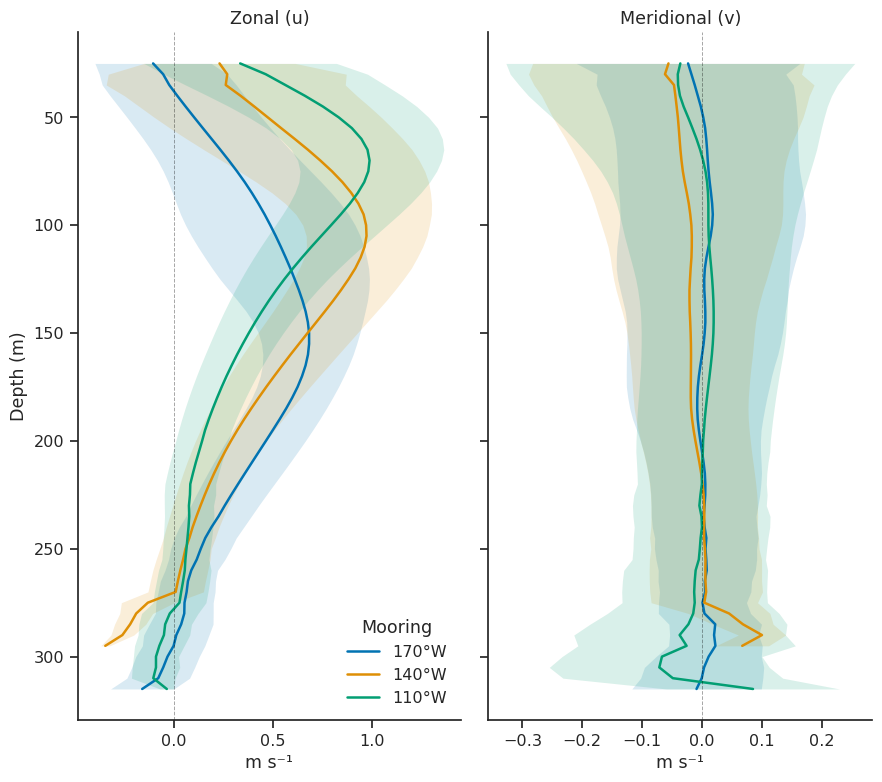

Saved: profiles/mean_std_profiles.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 8), sharey=True)

for label, color in MOORING_COLORS.items():
    for ax, da in zip(axes, [u[label], v[label]]):
        mean_prof = da.mean('time', skipna=True).values
        std_prof  = da.std('time',  skipna=True).values
        depths    = da.depth.values

        ax.plot(mean_prof, depths, color=color, label=label, lw=1.8)
        ax.fill_betweenx(depths, mean_prof - std_prof, mean_prof + std_prof,
                         color=color, alpha=0.15, linewidth=0)
for ax, title in zip(axes, ['Zonal (u)', 'Meridional (v)']):
    ax.set_xlabel('m s⁻¹')
    ax.set_title(title)
    ax.axvline(0, color='k', lw=0.7, ls='--', alpha=0.35)
    sns.despine(ax=ax)

axes[0].set_ylabel('Depth (m)')
axes[0].invert_yaxis()
axes[0].legend(title='Mooring', frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'profiles' / 'mean_std_profiles.png', **SAVE_KW)
plt.show()
print('Saved: profiles/mean_std_profiles.png')

## 5 — Spatial Structure at EUC-Relative Levels
Time-mean computed over the common record period of all three moorings.

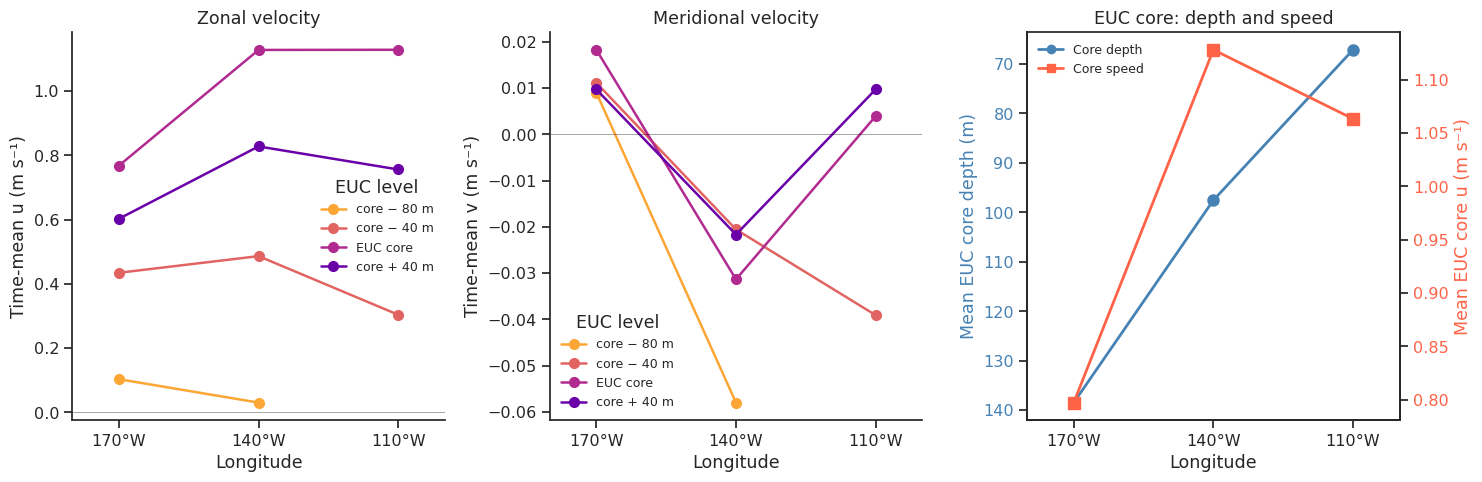

Saved: profiles/spatial_structure.png


In [11]:
# common time period (limited by 140°W)
t_start = max(ds.time.values[0]  for ds in datasets.values())
t_end   = min(ds.time.values[-1] for ds in datasets.values())

LONS_W     = [170, 140, 110]
LON_LABELS = ['170°W', '140°W', '110°W']
OFF_COLORS = sns.color_palette('plasma_r', len(EUC_OFFSETS))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, euc_dict, ylabel, title in zip(
    axes[:2],
    [u_rel, v_rel],
    ['Time-mean u (m s⁻¹)', 'Time-mean v (m s⁻¹)'],
    ['Zonal velocity', 'Meridional velocity'],
):
    for off, lbl, color in zip(EUC_OFFSETS, EUC_LABELS, OFF_COLORS):
        vals = []
        for label in MOORINGS:
            t = euc_times[label]
            mask = (t >= t_start) & (t <= t_end)
            vals.append(np.nanmean(euc_dict[label][mask, OFF_IDX[off]]))
        ax.plot(LONS_W, vals, 'o-', color=color, lw=1.8, ms=7, label=lbl)

    ax.axhline(0, color='k', lw=0.7, ls='-', alpha=0.35)
    ax.set_xticks(LONS_W)
    ax.set_xticklabels(LON_LABELS)
    ax.set_xlim(180, 100)
    ax.set_xlabel('Longitude')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='EUC level', frameon=False, fontsize=9)
    sns.despine(ax=ax)

# Panel 3: EUC core depth and peak speed vs longitude
ax3  = axes[2]
ax3b = ax3.twinx()

euc_d_mean = [np.nanmean(euc_core[m]) for m in MOORINGS]
euc_s_mean = [np.nanmean(get_level(u_rel[m], 0))  for m in MOORINGS]  # offset=0 = EUC core speed

ax3.plot( LONS_W, euc_d_mean, 'o-',  color='steelblue', lw=2.0, ms=8)
ax3b.plot(LONS_W, euc_s_mean, 's-', color='tomato',    lw=2.0, ms=8)
ax3.set_xticks(LONS_W)
ax3.set_xticklabels(LON_LABELS)
ax3.set_xlim(180, 100)
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Mean EUC core depth (m)', color='steelblue')
ax3b.set_ylabel('Mean EUC core u (m s⁻¹)', color='tomato')
ax3.tick_params(axis='y', labelcolor='steelblue')
ax3b.tick_params(axis='y', labelcolor='tomato')
ax3.invert_yaxis()
ax3.set_title('EUC core: depth and speed')
ax3.legend(handles=[
    Line2D([0], [0], color='steelblue', marker='o',  lw=2.0, label='Core depth'),
    Line2D([0], [0], color='tomato',    marker='s', ls='-', lw=2.0, label='Core speed'),
], frameon=False, fontsize=9)
sns.despine(ax=ax3, right=False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'profiles' / 'spatial_structure.png', **SAVE_KW)
plt.show()
print('Saved: profiles/spatial_structure.png')

## 6 — Pearson Correlation and Covariance at EUC-Relative Levels

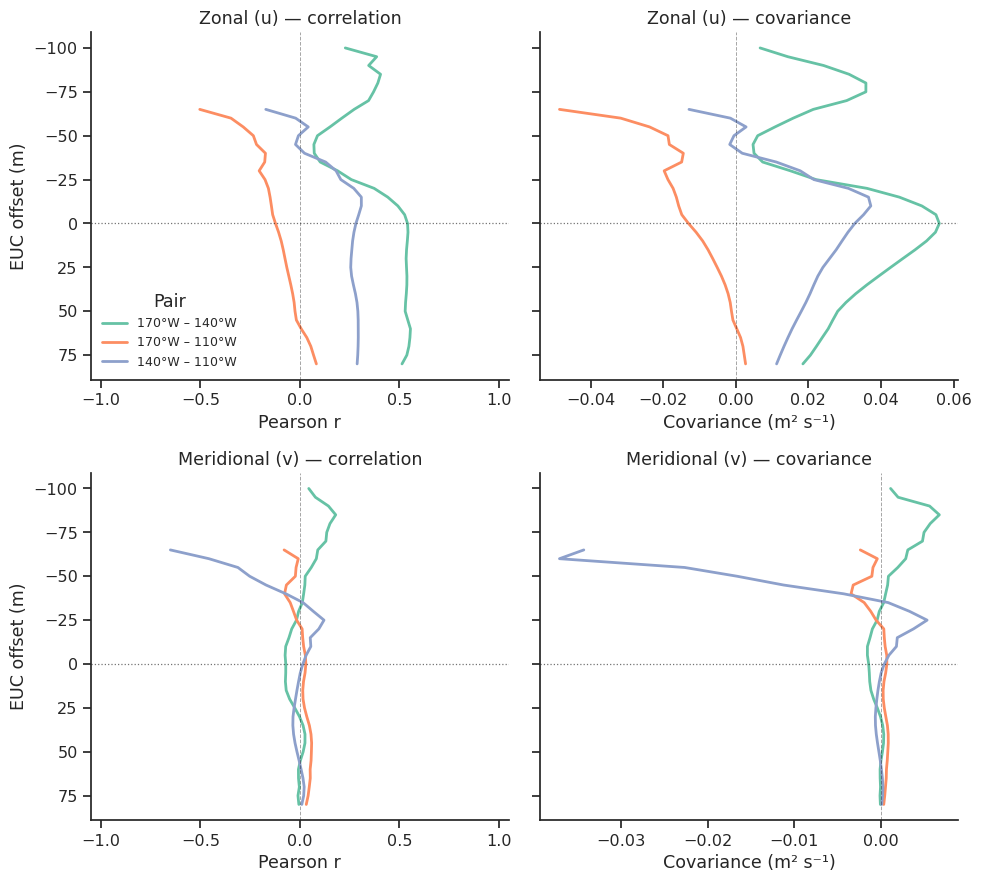

Saved: correlations/pearson_r_covariance_euc.png


In [12]:
def pearson_r_euc_profile(arr1, arr2, t1, t2, min_n=30):
    """Pearson r and covariance at each Z_REL level using co-valid, time-aligned samples."""
    _, idx1, idx2 = np.intersect1d(t1, t2, return_indices=True)
    a1 = arr1[idx1]; a2 = arr2[idx2]
    r_arr   = np.full(a1.shape[1], np.nan)
    cov_arr = np.full(a1.shape[1], np.nan)
    for iz in range(a1.shape[1]):
        x = a1[:, iz]; y = a2[:, iz]
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() >= min_n:
            r_arr[iz]   = stats.pearsonr(x[m], y[m])[0]
            cov_arr[iz] = np.cov(x[m], y[m], ddof=1)[0, 1]
    return r_arr, cov_arr

fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharey=True)

for (m1, m2), pair_label, color, ls in zip(PAIRS, PAIR_LABELS, PAIR_COLORS, PAIR_LS):
    r_u, cov_u = pearson_r_euc_profile(u_rel[m1], u_rel[m2], euc_times[m1], euc_times[m2])
    r_v, cov_v = pearson_r_euc_profile(v_rel[m1], v_rel[m2], euc_times[m1], euc_times[m2])
    axes[0, 0].plot(r_u,   Z_REL, color=color, lw=2.0, ls=ls, label=pair_label)
    axes[0, 1].plot(cov_u, Z_REL, color=color, lw=2.0, ls=ls, label=pair_label)
    axes[1, 0].plot(r_v,   Z_REL, color=color, lw=2.0, ls=ls, label=pair_label)
    axes[1, 1].plot(cov_v, Z_REL, color=color, lw=2.0, ls=ls, label=pair_label)

for row, rl in enumerate(["Zonal (u)", "Meridional (v)"]):
    axes[row, 0].set_xlabel("Pearson r")
    axes[row, 0].set_title(f"{rl} — correlation")
    axes[row, 0].set_xlim(-1.05, 1.05)
    axes[row, 0].axvline(0, color="k", lw=0.7, ls="--", alpha=0.35)
    axes[row, 0].set_ylabel("EUC offset (m)")
    axes[row, 1].set_xlabel("Covariance (m² s⁻¹)")
    axes[row, 1].set_title(f"{rl} — covariance")
    axes[row, 1].axvline(0, color="k", lw=0.7, ls="--", alpha=0.35)
    for ax in axes[row]:
        ax.axhline(0, color="k", lw=0.9, ls=":", alpha=0.55)
        sns.despine(ax=ax)

axes[0, 0].invert_yaxis()
axes[0, 0].legend(title="Pair", frameon=False, fontsize=9, loc="lower left")
plt.tight_layout()
fig.savefig(FIG_DIR / "correlations" / "pearson_r_covariance_euc.png", **SAVE_KW)
plt.show()
print("Saved: correlations/pearson_r_covariance_euc.png")

## 7 — Scatter Plots at EUC-Relative Levels
Color = ONI (red: El Niño, blue: La Niña).

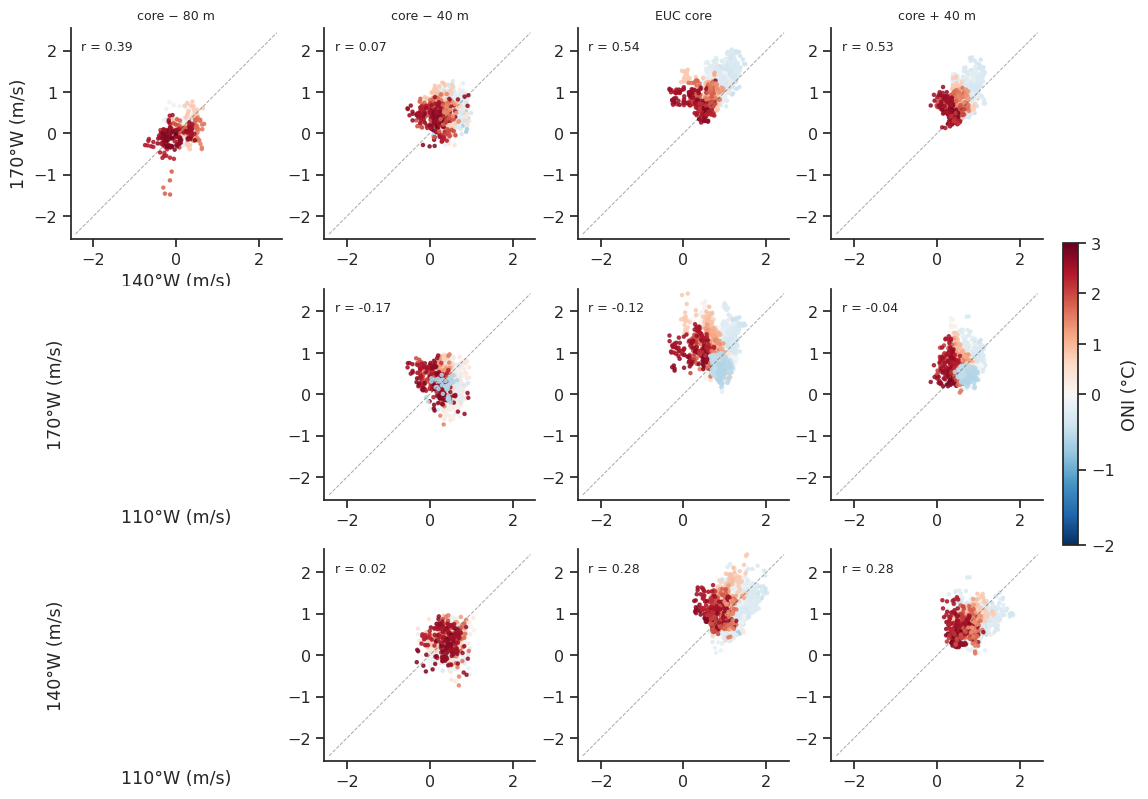

Saved: correlations/scatter_u.png


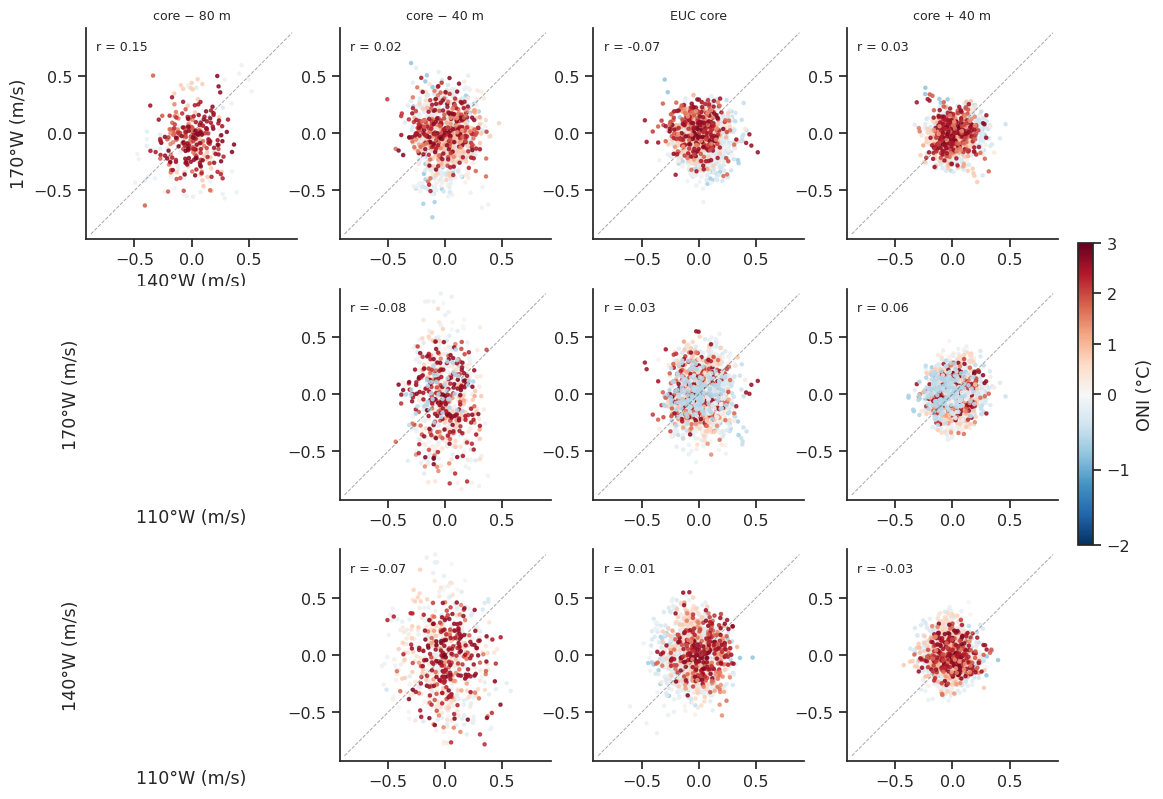

Saved: correlations/scatter_v.png


In [13]:
for euc_dict, fname in [(u_rel, 'scatter_u.png'), (v_rel, 'scatter_v.png')]:
    all_abs = []
    for m1, m2 in PAIRS:
        for off in EUC_OFFSETS:
            x, y, m, _ = align_pair_1d(
                get_level(euc_dict[m1], off), euc_times[m1],
                get_level(euc_dict[m2], off), euc_times[m2])
            if m.sum() > 0:
                all_abs.extend(np.abs(x[m]).tolist())
                all_abs.extend(np.abs(y[m]).tolist())
    global_lim = float(np.nanmax(np.abs(all_abs))) if all_abs else 1.0

    fig, axes = plt.subplots(len(PAIRS), len(EUC_OFFSETS),
                             figsize=(13, 3.2 * len(PAIRS)))

    for row, (m1, m2) in enumerate(PAIRS):
        for col, (off, lbl) in enumerate(zip(EUC_OFFSETS, EUC_LABELS)):
            ax = axes[row, col]

            # structural labels — title on row 0; both axis labels on col 0
            if row == 0:
                ax.set_title(lbl, fontsize=9)
            if col == 0:
                ax.set_ylabel(f'{m1} (m/s)')
                ax.set_xlabel(f'{m2} (m/s)')

            x, y, m, t_common = align_pair_1d(
                get_level(euc_dict[m1], off), euc_times[m1],
                get_level(euc_dict[m2], off), euc_times[m2])

            if m.sum() < 10:
                for sp in ax.spines.values(): sp.set_visible(False)
                ax.set_xticks([]); ax.set_yticks([])
                continue

            oni_c = get_oni(t_common)
            ax.scatter(x[m], y[m], c=oni_c[m],
                       cmap=ONI_CMAP, norm=ONI_NORM, s=5, alpha=0.8, rasterized=True)
            r_val = stats.pearsonr(x[m], y[m])[0]
            ax.text(0.05, 0.94, f'r = {r_val:.2f}',
                    transform=ax.transAxes, va='top', fontsize=9)
            ax.plot([-global_lim, global_lim], [-global_lim, global_lim],
                    'k--', lw=0.7, alpha=0.35)
            ax.set_xlim(-global_lim * 1.05, global_lim * 1.05)
            ax.set_ylim(-global_lim * 1.05, global_lim * 1.05)
            ax.set_aspect('equal')
            sns.despine(ax=ax)

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(cmap=ONI_CMAP, norm=ONI_NORM),
        ax=axes, orientation='vertical', fraction=0.015, pad=0.02
    )
    cbar.set_label('ONI (°C)')
    cbar.set_ticks([-2, -1, 0, 1, 2, 3])
    plt.savefig(FIG_DIR / 'correlations' / fname, **SAVE_KW)
    plt.show()
    print(f'Saved: correlations/{fname}')


## 8 — Velocity Hodographs at EUC-Relative Levels
u′ and v′ are anomalies relative to the time-mean at each EUC level. Color = ONI.

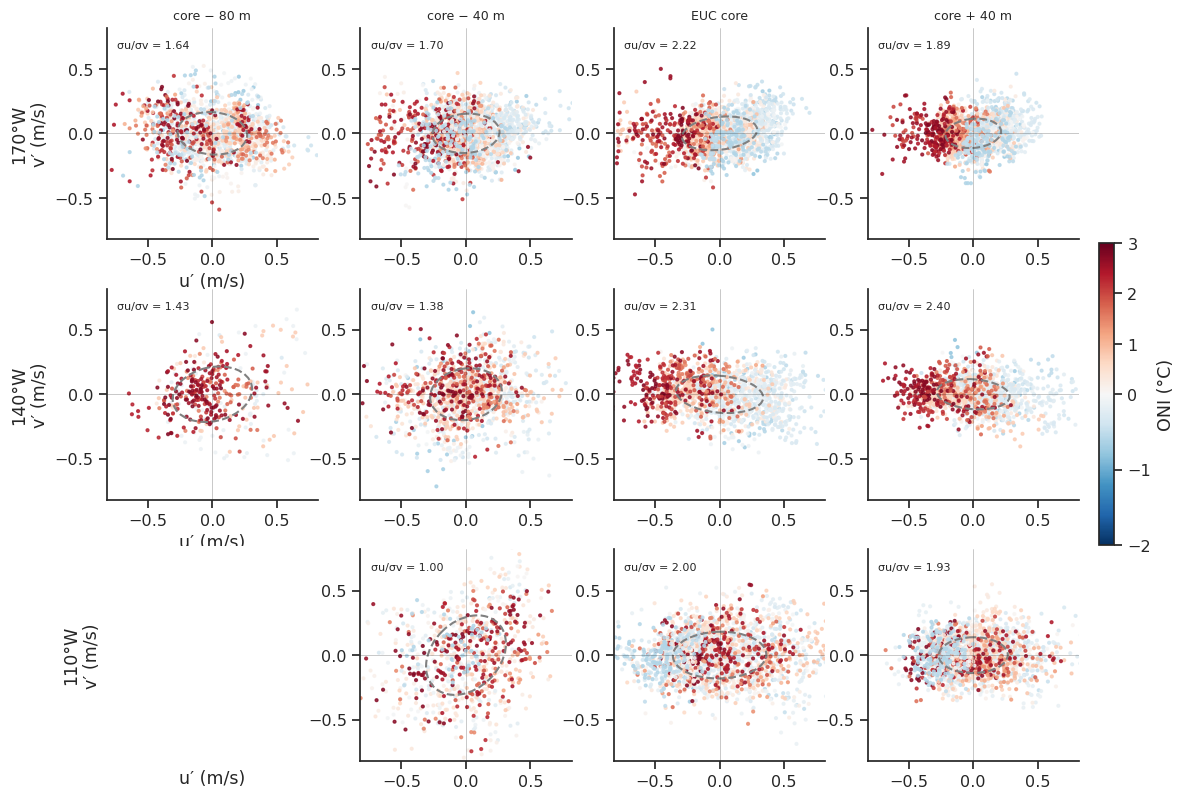

Saved: correlations/hodograph_uv.png


In [14]:
global_lim_hod = 0.0
for _lbl in MOORINGS:
    for _off in EUC_OFFSETS:
        _ut = get_level(u_rel[_lbl], _off).astype(float)
        _vt = get_level(v_rel[_lbl], _off).astype(float)
        _m  = np.isfinite(_ut) & np.isfinite(_vt)
        if _m.sum() >= 10:
            global_lim_hod = max(global_lim_hod, np.nanpercentile(
                np.abs(np.concatenate([_ut[_m] - _ut[_m].mean(),
                                       _vt[_m] - _vt[_m].mean()])), 99))

fig, axes = plt.subplots(len(MOORINGS), len(EUC_OFFSETS),
                         figsize=(13, 3.2 * len(MOORINGS)))

for row, label in enumerate(MOORINGS):
    t_vals   = euc_times[label]
    oni_vals = get_oni(t_vals)

    for col, (off, lbl) in enumerate(zip(EUC_OFFSETS, EUC_LABELS)):
        ax = axes[row, col]

        # structural labels — title on row 0; both axis labels on col 0
        if row == 0:
            ax.set_title(lbl, fontsize=9)
        if col == 0:
            ax.set_ylabel(f'{label}\nv\u2032 (m/s)')
            ax.set_xlabel("u\u2032 (m/s)")

        u_t = get_level(u_rel[label], off).astype(float)
        v_t = get_level(v_rel[label], off).astype(float)
        m   = np.isfinite(u_t) & np.isfinite(v_t)

        if m.sum() < 10:
            for sp in ax.spines.values(): sp.set_visible(False)
            ax.set_xticks([]); ax.set_yticks([])
            continue

        u_anom = u_t - np.nanmean(u_t[m])
        v_anom = v_t - np.nanmean(v_t[m])

        ax.scatter(u_anom[m], v_anom[m], c=oni_vals[m],
                   cmap=ONI_CMAP, norm=ONI_NORM, s=4, alpha=0.8, rasterized=True)

        cov_mat = np.cov(u_anom[m], v_anom[m])
        eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
        w = 2 * np.sqrt(np.abs(eigenvalues[1]))
        h = 2 * np.sqrt(np.abs(eigenvalues[0]))
        angle = np.degrees(np.arctan2(*eigenvectors[:, 1][::-1]))
        ax.add_patch(Ellipse(xy=(0, 0), width=w, height=h, angle=angle,
                             fc='none', ec='gray', lw=1.5, ls='--'))

        ax.set_xlim(-global_lim_hod, global_lim_hod)
        ax.set_ylim(-global_lim_hod, global_lim_hod)
        ax.set_aspect('equal')
        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.axvline(0, color='k', lw=0.5, alpha=0.3)

        ratio = np.std(u_anom[m]) / np.std(v_anom[m])
        ax.text(0.05, 0.94, f'\u03c3u/\u03c3v = {ratio:.2f}',
                transform=ax.transAxes, va='top', fontsize=8)
        sns.despine(ax=ax)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=ONI_CMAP, norm=ONI_NORM),
    ax=axes, orientation='vertical', fraction=0.015, pad=0.02
)
cbar.set_label('ONI (\u00b0C)')
cbar.set_ticks([-2, -1, 0, 1, 2, 3])
plt.savefig(FIG_DIR / 'correlations' / 'hodograph_uv.png', **SAVE_KW)
plt.show()
print('Saved: correlations/hodograph_uv.png')


## 9 — Lagged Cross-Correlation at EUC-Relative Levels
Positive lag means mooring 1 leads mooring 2.

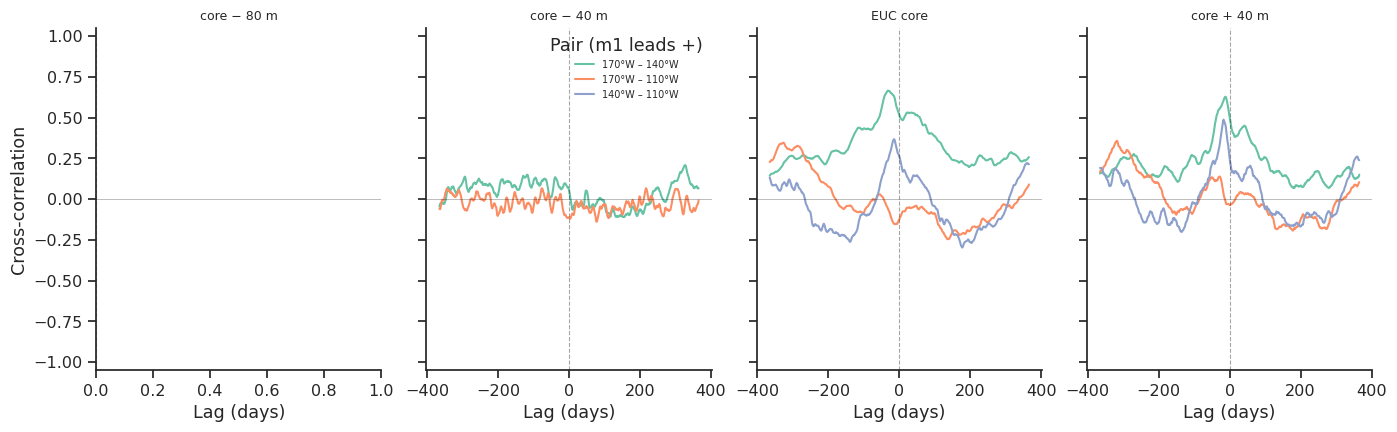

Saved: cross_correlation/lagged_xcorr_u.png


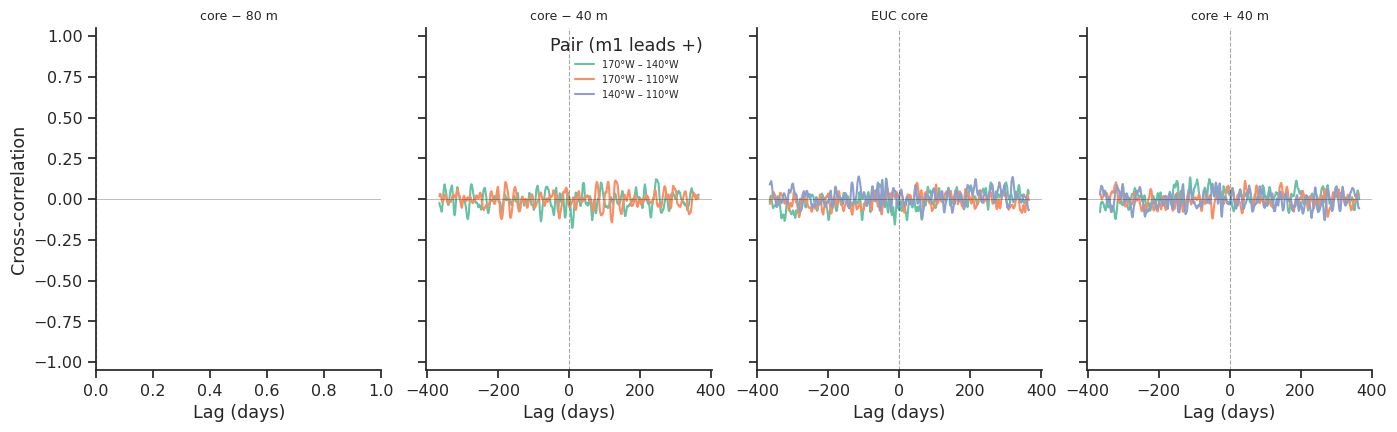

Saved: cross_correlation/lagged_xcorr_v.png


In [15]:
for euc_dict, fname in [(u_rel, "lagged_xcorr_u.png"), (v_rel, "lagged_xcorr_v.png")]:
    fig, axes = plt.subplots(1, len(EUC_OFFSETS), figsize=(14, 4.5), sharey=True)
    for col, (off, lbl) in enumerate(zip(EUC_OFFSETS, EUC_LABELS)):
        ax = axes[col]
        for (m1, m2), pair_label, color, ls in zip(PAIRS, PAIR_LABELS, PAIR_COLORS, PAIR_LS):
            x, y, _, _ = align_pair_1d(
                get_level(euc_dict[m1], off), euc_times[m1],
                get_level(euc_dict[m2], off), euc_times[m2],
            )
            lags, xc = lagged_xcorr_1d(x, y)
            if lags is not None:
                ax.plot(lags, xc, color=color, lw=1.5, ls=ls, label=pair_label)
        ax.axhline(0, color="k", lw=0.6, alpha=0.3)
        ax.axvline(0, color="k", lw=0.8, ls="--", alpha=0.35)
        ax.set_xlabel("Lag (days)")
        ax.set_title(lbl, fontsize=9)
        ax.set_ylim(-1.05, 1.05)
        sns.despine(ax=ax)
    axes[0].set_ylabel("Cross-correlation")
    from matplotlib.lines import Line2D as _L2D
    _leg_h = [_L2D([0],[0], color=c, lw=1.5, ls=s, label=l)
              for l, c, s in zip(PAIR_LABELS, PAIR_COLORS, PAIR_LS)]
    axes[1].legend(handles=_leg_h, title="Pair (m1 leads +)", frameon=False, fontsize=7)
    plt.tight_layout()
    fig.savefig(FIG_DIR / "cross_correlation" / fname, **SAVE_KW)
    plt.show()
    print(f"Saved: cross_correlation/{fname}")

In [16]:

import scipy.ndimage as _ndimage
import matplotlib.dates as _mdates
from matplotlib.ticker import FuncFormatter as _FmtFn

(FIG_DIR / 'wavelet_coherence').mkdir(exist_ok=True)


def _morlet_cwt(x, scales, omega0=6.0):
    n = len(x)
    N = int(2 ** np.ceil(np.log2(n + 1)))
    Xf = np.fft.fft(np.append(x - x.mean(), np.zeros(N - n)))
    k  = np.fft.fftfreq(N) * 2 * np.pi
    W  = np.empty((len(scales), n), dtype=complex)
    for i, s in enumerate(scales):
        psi = np.sqrt(2 * np.pi * s) * np.pi**(-0.25) * np.exp(-0.5 * (s * k - omega0) ** 2)
        psi[k <= 0] = 0
        W[i] = np.fft.ifft(Xf * psi)[:n]
    return W


def wavelet_coherence(x, y, omega0=6.0, nvoice=12):
    """Squared wavelet coherence (Morlet). Periods span 20 d to min(2 yr, N/4).
    COI and NaN input positions are masked (returned as NaN)."""
    n = len(x)
    ff    = (4 * np.pi) / (omega0 + np.sqrt(2 + omega0 ** 2))
    s0    = 20.0 / ff
    s_max = min(730.0, n / 4) / ff
    n_sc  = int(np.log2(s_max / s0) * nvoice) + 1
    scales  = s0 * 2 ** (np.arange(n_sc) / nvoice)
    periods = scales * ff

    mx, my = np.isfinite(x), np.isfinite(y)
    xf = np.where(mx, x, np.nanmean(x) if mx.any() else 0.0)
    yf = np.where(my, y, np.nanmean(y) if my.any() else 0.0)
    Wx  = _morlet_cwt(xf, scales, omega0)
    Wy  = _morlet_cwt(yf, scales, omega0)
    Wxy = Wx * np.conj(Wy)

    Wxy_sm = np.empty_like(Wxy)
    Wxx_sm = np.empty(Wxy.shape, dtype=float)
    Wyy_sm = np.empty(Wxy.shape, dtype=float)
    for i, s in enumerate(scales):
        sig = max(0.6 * s, 0.5)
        Wxy_sm[i] = (_ndimage.gaussian_filter1d(Wxy[i].real, sig) +
                     1j * _ndimage.gaussian_filter1d(Wxy[i].imag, sig))
        Wxx_sm[i] = _ndimage.gaussian_filter1d(np.abs(Wx[i]) ** 2, sig)
        Wyy_sm[i] = _ndimage.gaussian_filter1d(np.abs(Wy[i]) ** 2, sig)
    sw     = max(1, int(0.6 * nvoice))
    Wxy_sm = (_ndimage.uniform_filter1d(Wxy_sm.real, sw, axis=0) +
               1j * _ndimage.uniform_filter1d(Wxy_sm.imag, sw, axis=0))
    Wxx_sm = _ndimage.uniform_filter1d(Wxx_sm, sw, axis=0)
    Wyy_sm = _ndimage.uniform_filter1d(Wyy_sm, sw, axis=0)

    wtc   = np.clip(np.abs(Wxy_sm) ** 2 / (Wxx_sm * Wyy_sm + 1e-20), 0, 1)
    phase = np.angle(Wxy_sm)

    t   = np.arange(n)
    coi = ff * np.sqrt(2) * np.minimum(t, n - 1 - t)
    wtc[periods[:, None] > coi[None, :]] = np.nan
    wtc[:, (~mx) | (~my)] = np.nan
    phase[np.isnan(wtc)] = np.nan
    return wtc, phase, periods, coi


def _wtc_panel(ax, t_dt64, wtc, phase, periods, coi,
               col_title='', row_label='',
               first_col=False, last_row=False, draw_title=False, yr_step=1):
    """Draw one WTC panel: high-coherence regions in magma, low-coh dark, COI opaque."""
    tf = _mdates.date2num(t_dt64.astype('datetime64[ms]').astype('O'))
    T, P = np.meshgrid(tf, periods)

    # Dark background for inside-COI, low-coherence regions
    ax.pcolormesh(T, P, np.where(np.isfinite(wtc), 1.0, np.nan),
                   cmap='Greys', vmin=0, vmax=1, shading='auto', zorder=0)

    # High-coherence signal (>= 0.5) in magma
    _cmap = plt.cm.viridis.copy()
    _cmap.set_bad(color='none')
    wtc_hi = np.where(np.isfinite(wtc) & (wtc >= 0.5), wtc, np.nan)
    im = ax.pcolormesh(T, P, wtc_hi, cmap=_cmap,
                        vmin=0.5, vmax=1.0, shading='auto', zorder=1)

    ax.set_yscale('log')
    ax.set_ylim(periods.min(), periods.max())
    ax.xaxis_date()

    # COI fully opaque
    coi_p = np.clip(coi, periods.min(), periods.max())
    ax.fill_between(t_dt64.astype('datetime64[ms]').astype('O'),
                    coi_p, periods.max(), color='0.5', alpha=1.0, lw=0, zorder=2)

    # Period axis — named ticks only
    yticks = [v for v in [20, 32, 64, 128, 256, 365, 730]
              if periods.min() <= v <= periods.max()]
    ax.set_yticks(yticks)
    ax.yaxis.set_minor_locator(plt.NullLocator())
    if first_col:
        lbl = (row_label + '\nPeriod (days)') if row_label else 'Period (days)'
        ax.set_ylabel(lbl, fontsize=7)
        ax.yaxis.set_major_formatter(
            _FmtFn(lambda v, _: (f'{int(v)}d' if v < 365 else f'{v/365:.1f}yr')))
    else:
        ax.yaxis.set_major_formatter(_FmtFn(lambda v, _: ''))

    if last_row:
        ax.xaxis.set_major_locator(_mdates.YearLocator(yr_step))
        ax.xaxis.set_major_formatter(_mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', labelsize=7)
        ax.set_xlabel('Time', fontsize=7)
    else:
        ax.xaxis.set_major_formatter(_FmtFn(lambda v, _: ''))

    if draw_title:
        ax.set_title(col_title, fontsize=8)
    sns.despine(ax=ax)
    return im


In [17]:

_YR = 5 if 'full_record' in str(FIG_DIR) else 1

for _comp, _euc in [('u', u_rel), ('v', v_rel)]:
    for focal in MOORINGS:
        others   = [m for m in MOORINGS if m != focal]
        n_r, n_c = len(others), len(EUC_OFFSETS)
        fig, axes = plt.subplots(n_r, n_c, figsize=(4.2 * n_c, 3.2 * n_r), squeeze=False, constrained_layout=True)
        _im = None
        for row, other in enumerate(others):
            t1, t2 = euc_times[focal], euc_times[other]
            _, idx1, idx2 = np.intersect1d(t1, t2, return_indices=True)
            t_common = t1[idx1]
            for col, (off, lbl) in enumerate(zip(EUC_OFFSETS, EUC_LABELS)):
                ax = axes[row, col]
                if row == 0:
                    ax.set_title(lbl, fontsize=8)
                x = get_level(_euc[focal], off)[idx1]
                y = get_level(_euc[other],  off)[idx2]
                if np.isfinite(x).sum() < 100:
                    for sp in ax.spines.values(): sp.set_visible(False)
                    ax.set_xticks([]); ax.set_yticks([])
                    if col == 0:
                        ax.set_ylabel(f'{focal} vs {other}\nPeriod (days)', fontsize=7)
                    ax.set_xlabel('Time', fontsize=7)
                    continue
                wtc, phase, periods, coi = wavelet_coherence(x, y)
                _im = _wtc_panel(ax, t_common, wtc, phase, periods, coi,
                                  col_title=lbl,
                                  row_label=f'{focal} vs {other}',
                                  first_col=(col == 0),
                                  last_row=True,
                                  draw_title=(row == 0),
                                  yr_step=_YR)
        if _im is not None:
            cb = fig.colorbar(_im, ax=axes, fraction=0.015, pad=0.02)
            cb.set_label('Coherence'); cb.set_ticks([0, .25, .5, .75, 1])
        _safe = focal.replace('°', '').replace(' ', '_')
        _fn   = f'wavelet_coherence_{_comp}_{_safe}.png'
        fig.suptitle(f'Wavelet Coherence (EUC) — {focal}, {_comp.upper()}',
                     fontsize=10, y=1.01)
        fig.savefig(FIG_DIR / 'wavelet_coherence' / _fn, **SAVE_KW)
        plt.close()
        print(f'Saved: wavelet_coherence/{_fn}')


Saved: wavelet_coherence/wavelet_coherence_u_170W.png


Saved: wavelet_coherence/wavelet_coherence_u_140W.png


Saved: wavelet_coherence/wavelet_coherence_u_110W.png


Saved: wavelet_coherence/wavelet_coherence_v_170W.png


Saved: wavelet_coherence/wavelet_coherence_v_140W.png


Saved: wavelet_coherence/wavelet_coherence_v_110W.png


In [18]:

from scipy.signal.windows import hann as _hann

(FIG_DIR / 'cross_spectral').mkdir(exist_ok=True)

# Mooring longitudes (decimal degrees east)
_LON = {}
for _m in MOORINGS:
    if '°W' in _m:
        _LON[_m] = -float(_m.replace('°W', ''))
    elif '°E' in _m:
        _LON[_m] = float(_m.replace('°E', ''))

# Eastward separation (m): positive = m2 is east of m1 (wraps date line)
PAIR_SEP_M = {}
for _m1, _m2 in PAIRS:
    _dl = _LON[_m2] - _LON[_m1]
    if _dl > 180:  _dl -= 360
    if _dl < -180: _dl += 360
    PAIR_SEP_M[(_m1, _m2)] = _dl * 111_320.0


def _max_gap(valid_mask):
    """Length of the longest consecutive-NaN run."""
    if valid_mask.all(): return 0
    d = np.diff(np.concatenate([[1], valid_mask.astype(int), [1]]))
    starts = np.where(d == -1)[0]; ends = np.where(d == 1)[0]
    return int((ends - starts).max()) if len(starts) else 0


def cross_spectral_welch(x, y, seg_days=730, overlap=0.5, max_gap=14):
    """
    Welch cross-spectral coherence between daily time series x, y.

    Gaps <= max_gap days are linearly interpolated per segment.
    Segments containing longer gaps are skipped.

    Returns: (periods_days, coh2, phase_rad, n_segs)
    - periods: 1/freq, days
    - coh2: coherence squared [0, 1]
    - phase: positive = x leads y
    Returns (None, None, None, 0) if fewer than 2 valid segments.
    """
    n = len(x); L = int(seg_days); step = int(L * (1 - overlap))
    win = _hann(L); win_ss = win @ win

    Sxx = np.zeros(L // 2 + 1)
    Syy = np.zeros(L // 2 + 1)
    Sxy = np.zeros(L // 2 + 1, dtype=complex)
    n_segs = 0

    for s in range(0, n - L + 1, step):
        xs = x[s:s+L].copy().astype(float)
        ys = y[s:s+L].copy().astype(float)
        mx = np.isfinite(xs); my = np.isfinite(ys)

        if _max_gap(mx) > max_gap or _max_gap(my) > max_gap:
            continue

        t = np.arange(L, dtype=float)
        if not mx.all(): xs = np.interp(t, t[mx], xs[mx])
        if not my.all(): ys = np.interp(t, t[my], ys[my])

        xs -= np.polyval(np.polyfit(t, xs, 1), t); xs *= win
        ys -= np.polyval(np.polyfit(t, ys, 1), t); ys *= win

        Xf = np.fft.rfft(xs); Yf = np.fft.rfft(ys)
        Sxy += Xf * np.conj(Yf)
        Sxx += (Xf * np.conj(Xf)).real
        Syy += (Yf * np.conj(Yf)).real
        n_segs += 1

    if n_segs < 2:
        return None, None, None, 0

    freqs = np.fft.rfftfreq(L, d=1.0)[1:]       # skip DC
    coh2  = np.clip(np.abs(Sxy[1:] / n_segs) ** 2 /
                    (Sxx[1:] * Syy[1:] / n_segs ** 2 + 1e-30), 0, 1)
    phase = np.angle(Sxy[1:])
    return 1.0 / freqs, coh2, phase, n_segs


def coh2_thresh(n_segs, alpha=0.05):
    """Coherence² significance threshold for K-segment Welch estimate."""
    return 1.0 - alpha ** (1.0 / (n_segs - 1))


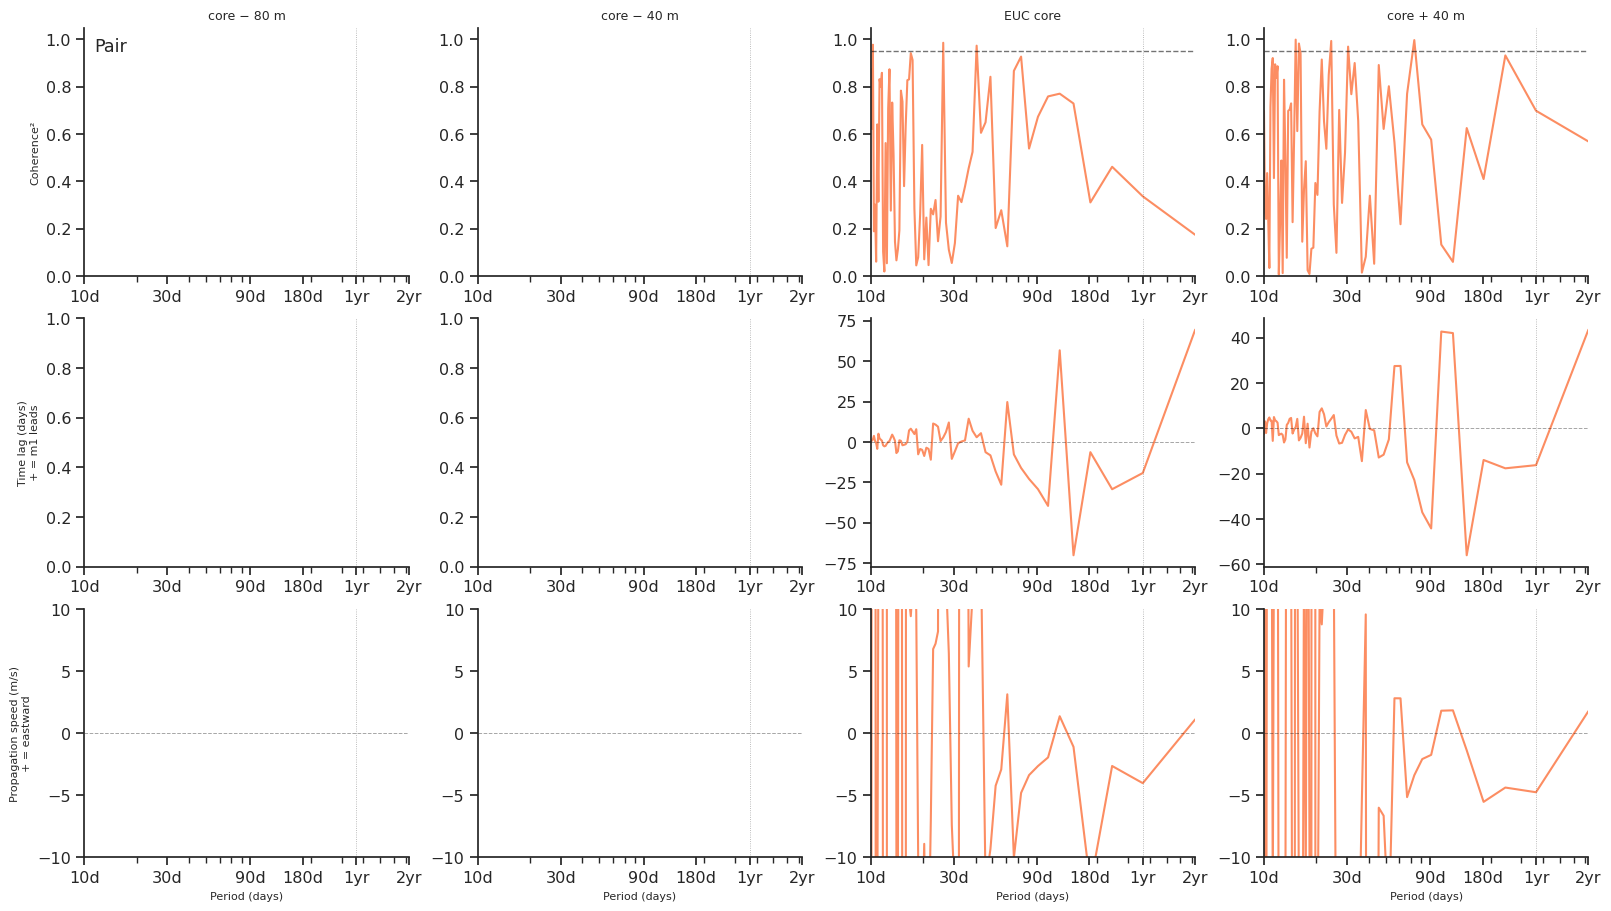

Saved: cross_spectral/cross_spectral_u.png


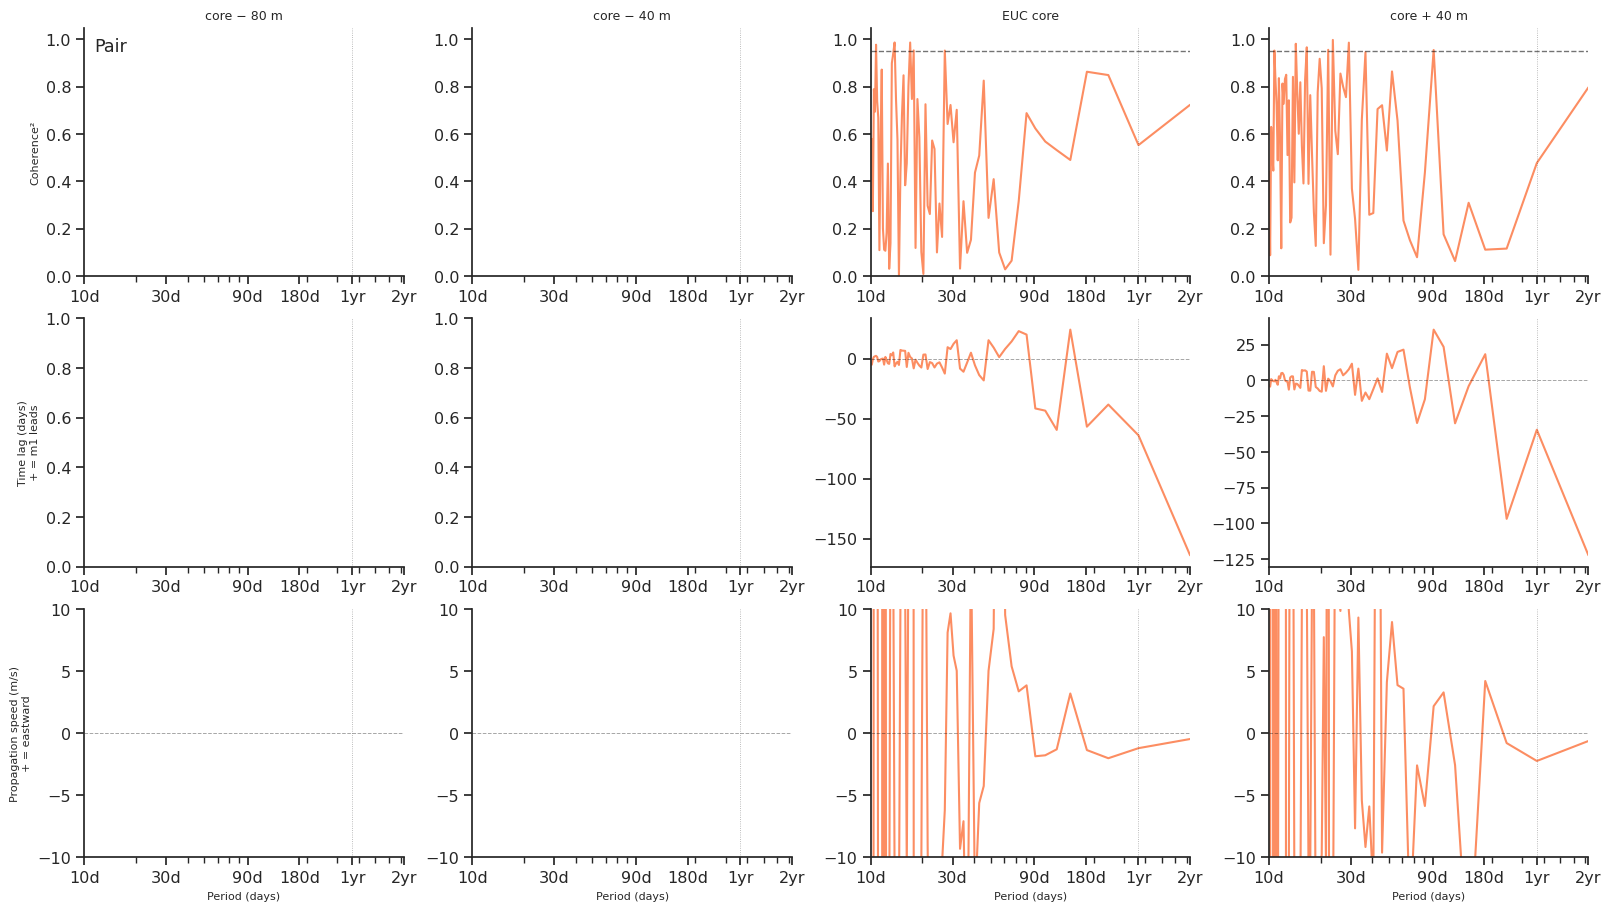

Saved: cross_spectral/cross_spectral_v.png


In [19]:

SELECT_OFFSETS_CS = EUC_OFFSETS          # e.g. [-80, -40, 0, 40]
PMIN, PMAX = 10.0, 730.0

_PTICKS = [10, 30, 90, 180, 365, 730]

for comp, euc_dict, fname in [('u', u_rel, 'cross_spectral_u.png'),
                                ('v', v_rel, 'cross_spectral_v.png')]:
    fig, axes = plt.subplots(3, len(SELECT_OFFSETS_CS),
                              figsize=(4.0 * len(SELECT_OFFSETS_CS), 9),
                              constrained_layout=True)

    for col, (off, off_lbl) in enumerate(zip(SELECT_OFFSETS_CS, EUC_LABELS)):
        ax_c  = axes[0, col]
        ax_t  = axes[1, col]
        ax_sp = axes[2, col]

        ax_c.set_title(off_lbl, fontsize=9)
        if col == 0:
            ax_c.set_ylabel('Coherence²', fontsize=8)
            ax_t.set_ylabel('Time lag (days)\n+ = m1 leads', fontsize=8)
            ax_sp.set_ylabel('Propagation speed (m/s)\n+ = eastward', fontsize=8)
        ax_sp.set_xlabel('Period (days)', fontsize=8)

        _thresh_drawn = False
        for (m1, m2), pair_label, color, ls in zip(PAIRS, PAIR_LABELS, PAIR_COLORS, PAIR_LS):
            t1, t2 = euc_times[m1], euc_times[m2]
            _, idx1, idx2 = np.intersect1d(t1, t2, return_indices=True)
            x = get_level(euc_dict[m1], off)[idx1]
            y = get_level(euc_dict[m2], off)[idx2]
            if np.isfinite(x).sum() < 100:
                continue

            periods, coh2, phase, n_segs = cross_spectral_welch(x, y)
            if periods is None:
                continue

            mask = (periods >= PMIN) & (periods <= PMAX)
            p  = periods[mask][::-1]
            c  = coh2[mask][::-1]
            ph = phase[mask][::-1]

            lag_days = ph * p / (2 * np.pi)
            sep_m    = PAIR_SEP_M.get((m1, m2), np.nan)
            speed_ms = sep_m / (lag_days * 86_400 + 1e-30)

            ax_c.plot(p, c,         color=color, lw=1.5, ls=ls, label=pair_label)
            ax_t.plot(p, lag_days,  color=color, lw=1.5, ls=ls)
            ax_sp.plot(p, speed_ms, color=color, lw=1.5, ls=ls)

            if not _thresh_drawn:
                thr = coh2_thresh(n_segs)
                ax_c.axhline(thr, color='k', ls='--', lw=1.0, alpha=0.55,
                             label=f'95% (K={n_segs})')
                _thresh_drawn = True

        for ax in (ax_c, ax_t, ax_sp):
            ax.set_xscale('log'); ax.set_xlim(PMIN, PMAX)
            ax.set_xticks(_PTICKS)
            ax.xaxis.set_major_formatter(
                plt.FuncFormatter(lambda v, _: f'{int(v)}d' if v < 365 else f'{v/365:.0f}yr'))
            ax.axvline(365, color='k', lw=0.6, ls=':', alpha=0.35)
            sns.despine(ax=ax)

        ax_c.set_ylim(0, 1.05)
        ax_t.axhline(0, color='k', lw=0.7, ls='--', alpha=0.35)
        ax_sp.axhline(0, color='k', lw=0.7, ls='--', alpha=0.35)
        ax_sp.set_ylim(-10, 10)

    axes[0, 0].legend(title='Pair', frameon=False, fontsize=8, loc='upper left')
    fig.savefig(FIG_DIR / 'cross_spectral' / fname, **SAVE_KW)
    plt.show()
    print(f'Saved: cross_spectral/{fname}')
